<a href="https://colab.research.google.com/github/princepatel2004/Edunet-Summer-Intership-/blob/main/%5BDay_7%5D_13_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 7 13-07-2026 K Means Clustering

# Import Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("/sustainability_kmeans_dataset.csv")
df.head()

,State,Solar_MW,Wind_MW,Energy_Consumption_GWh,Carbon_Emissions_tCO2,Recycling_Rate_pct,Water_Use_MLD
0,Rajasthan,704.0,3137.0,4455.5,1830.0,35.6,615.5
1,Rajasthan,3956.0,NaN,4343.4,1857.5,35.3,453.7
2,Odisha,2305.0,1939.0,6344.8,2663.2,76.7,104.5
3,Odisha,3287.0,1238.0,4960.9,2072.4,87.0,335.6
4,Rajasthan,3440.0,3571.0,7503.7,3017.7,38.5,130.4


# Information about Dataset

In [4]:
print("Rows and Columns :", df.shape)
df.columns
df.info()

Rows and Columns : (120, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   120 non-null    object 
 1   Solar_MW                119 non-null    float64
 2   Wind_MW                 117 non-null    float64
 3   Energy_Consumption_GWh  119 non-null    float64
 4   Carbon_Emissions_tCO2   117 non-null    float64
 5   Recycling_Rate_pct      117 non-null    float64
 6   Water_Use_MLD           119 non-null    float64
dtypes: float64(6), object(1)
memory usage: 6.7+ KB


# Handle Missing Values

In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

df["State"] = df["State"].fillna(df["State"].mode()[0])

# Check Duplicate Records

In [7]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

0


# Exploratory Data Analysis (EDA)

Analyze the dataset using summary statistics and visualizations.

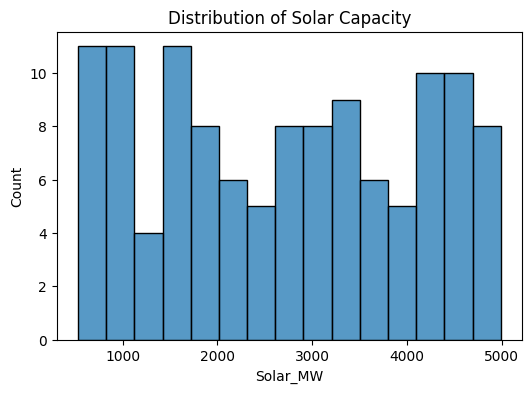

In [8]:
# Histogram
plt.figure(figsize=(6,4))

sns.histplot(df["Solar_MW"], bins=15)
plt.title("Distribution of Solar Capacity")
plt.show()

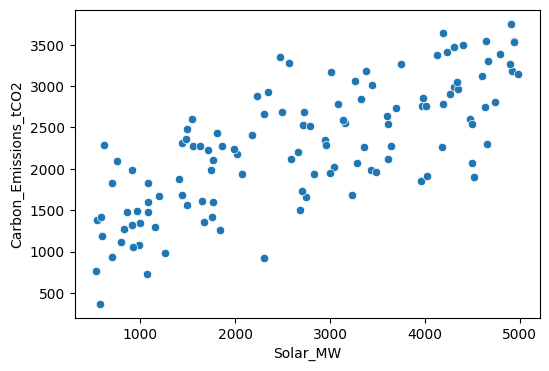

In [9]:
# Scatter plot
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Solar_MW",
    y="Carbon_Emissions_tCO2",
    data=df
)

plt.show()

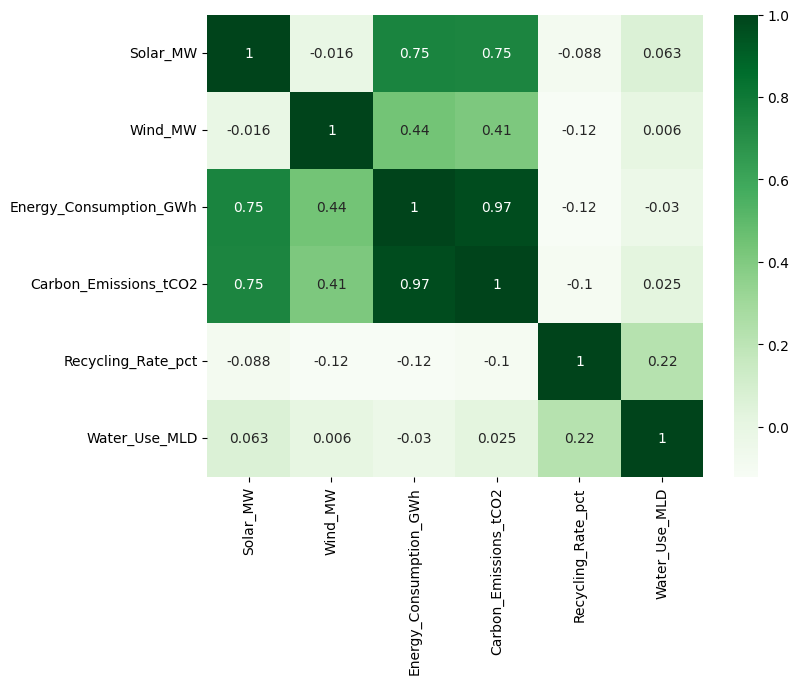

In [10]:
# Correlational Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Greens"
)

plt.show()

# Feature Selection

Only numerical features are selected for clustering.

In [11]:
X = df[numeric_columns]
X.head()

,Solar_MW,Wind_MW,Energy_Consumption_GWh,Carbon_Emissions_tCO2,Recycling_Rate_pct,Water_Use_MLD
0,704.0,3137.000000,4455.5,1830.0,35.6,615.5
1,3956.0,2035.282051,4343.4,1857.5,35.3,453.7
2,2305.0,1939.000000,6344.8,2663.2,76.7,104.5
3,3287.0,1238.000000,4960.9,2072.4,87.0,335.6
4,3440.0,3571.000000,7503.7,3017.7,38.5,130.4


# Feature Scaling

Standardize the data before applying K-Means because it is distance-based.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method

Find the optimal number of clusters.

In [13]:
inertia = []

K = range(1,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

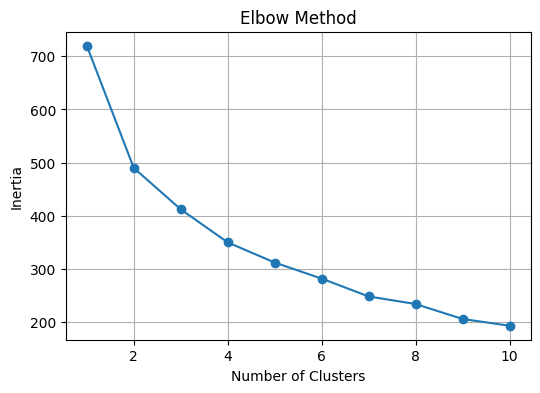

In [14]:
plt.figure(figsize=(6,4))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")
plt.grid(True)

plt.show()

# Model Training

Choose the optimal number of clusters based on the Elbow Method.

(Assume K = 2.)

In [27]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# Cluster Visualization

Visualize clusters using Solar Capacity and Carbon Emissions

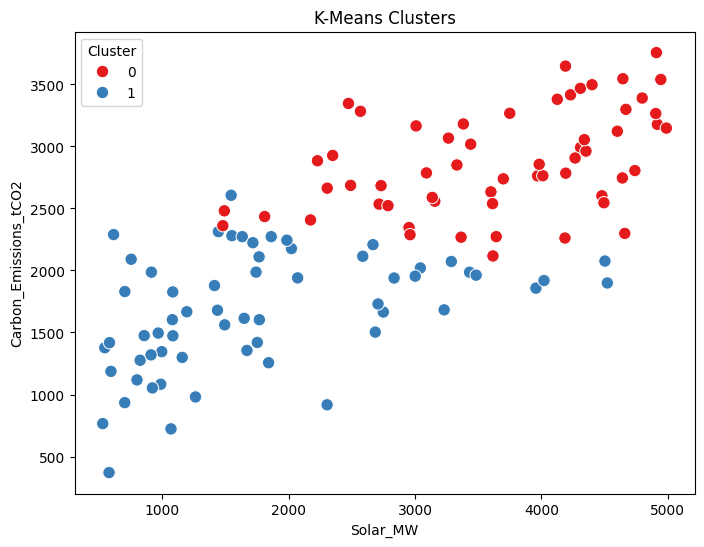

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Solar_MW",
    y="Carbon_Emissions_tCO2",
    hue="Cluster",
    palette="Set1",
    data=df,
    s=80
)

plt.title("K-Means Clusters")

plt.show()

# Cluster Summary

Analyze the average values within each cluster.

In [29]:
df.groupby("Cluster").mean(numeric_only=True)

,Solar_MW,Wind_MW,Energy_Consumption_GWh,Carbon_Emissions_tCO2,Recycling_Rate_pct,Water_Use_MLD
Cluster,,,,,,
0,3674.297821,2374.852238,6999.901111,2888.641460,54.900348,421.544666
1,1788.278689,1706.845313,4339.765574,1676.847415,58.284279,457.132787


# Model Evaluation

Evaluate clustering using the Silhouette Score.

In [30]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.262575588926326


# Interpretation of Silhouette Score

0.70–1.00: Excellent clustering

0.50–0.69: Good clustering

0.25–0.49: Acceptable clustering

Below 0.25: Weak clustering

# Conclusion
##Observations

 • Missing values were handled using the mean for numerical columns.

 • Duplicate records were checked and removed if present.

 • Numerical features were standardized using StandardScaler.

 • The Elbow Method was used to determine the optimal number of clusters.

 • K-Means grouped similar sustainability records into three clusters.

 • The Silhouette Score indicated the quality of the clustering.

 • The clustering can help identify regions with similar renewable energy usage, emissions, recycling rates, and water consumption, supporting sustainability planning and policy decisions.


This task fulfills the expected workflow:
dataset loading, cleaning, EDA with Seaborn, feature scaling, K-Means clustering, cluster visualization, evaluation with the Elbow Method and Silhouette Score, and final observations.